#MODEL

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving all_years.xlsx to all_years.xlsx


In [ ]:
import pandas as pd

df = pd.read_excel("all_years.xlsx")
#df = pd.read_excel("artemis_dataset_release_v0_sorted.xlsx")

print(df)

       game_id       date  season home_short_display_name  home_SRS  home_SOS  \
0    401522202 2023-04-03    2023                   UConn     22.95      8.51   
1    401522200 2023-04-01    2023            San Diego St     15.81      8.92   
2    401522201 2023-04-01    2023                   UConn     22.95      8.51   
3    401522199 2023-03-26    2023            San Diego St     15.81      8.92   
4    401522196 2023-03-26    2023                   Texas     20.56     10.43   
..         ...        ...     ...                     ...       ...       ...   
509  254000054 2005-03-17    2005                     LSU     11.60      7.77   
510  254000008 2005-03-17    2005              Texas Tech     16.23      9.11   
511  254000055 2005-03-17    2005                 Arizona     18.00      8.02   
512  254000039 2005-03-17    2005                    Utah     14.00      4.53   
513  254000009 2005-03-17    2005                 Gonzaga     13.29      4.36   

     home_Tm.  home_Opp.  h

In [ ]:
df = df.drop(columns=["game_id","date"])

KeyError: "['game_id', 'date'] not found in axis"

In [ ]:
X_train = df[df['season'] != 2023].drop(columns=['underdog_winner', 'home_score', 'away_score', 'home_short_display_name', 'away_short_display_name'])
y_train = df[df['season'] != 2023]['underdog_winner']

##Watch this
- this one drops the NaN values, try one where they are set to 0

###log
- 2005: 67.2
- 2006: 67.5
- 2007: 67.7
- 2008: 68.6
- 2009: 66.3

In [ ]:
y2023 = df.query("season == 2023")

y_test = y2023['underdog_winner']
X_test_drop = y2023.drop(columns=['underdog_winner', 'home_score', 'away_score', 'home_short_display_name', 'away_short_display_name', 'away_ORB%', 'away_STL%', 'away_ORtg', 'away_Pace', 'home_ORB%', 'home_STL%', 'home_ORtg', 'home_Pace'])
X_test = y2023.drop(columns=['underdog_winner', 'home_score', 'away_score', 'home_short_display_name', 'away_short_display_name'])
X_test_manual = X_test.copy()
X_test_manual.loc[X_test_manual['season'] == 2005] = X_test_manual.loc[X_test_manual['season'] == 2005].fillna(67.2)
X_test_manual.loc[X_test_manual['season'] == 2006] = X_test_manual.loc[X_test_manual['season'] == 2006].fillna(67.5)
X_test_manual.loc[X_test_manual['season'] == 2007] = X_test_manual.loc[X_test_manual['season'] == 2007].fillna(67.7)
X_test_manual.loc[X_test_manual['season'] == 2008] = X_test_manual.loc[X_test_manual['season'] == 2008].fillna(68.6)
X_test_manual.loc[X_test_manual['season'] == 2009] = X_test_manual.loc[X_test_manual['season'] == 2009].fillna(66.3)
X_test_mean = X_test.fillna(X_test.mean())
X_test = X_test.fillna(0)

print(y_test)

0     False
1     False
2     False
3     False
4      True
      ...  
62    False
63     True
64    False
65     True
66    False
Name: underdog_winner, Length: 67, dtype: bool


In [ ]:
X_train_drop = X_train.drop(columns=['away_ORB%', 'away_STL%', 'away_ORtg', 'away_Pace', 'home_ORB%', 'home_STL%', 'home_ORtg', 'home_Pace'])
X_train_manual = X_train.copy()
X_train_manual.loc[X_train_manual['season'] == 2005] = X_train_manual.loc[X_train_manual['season'] == 2005].fillna(67.2)
X_train_manual.loc[X_train_manual['season'] == 2006] = X_train_manual.loc[X_train_manual['season'] == 2006].fillna(67.5)
X_train_manual.loc[X_train_manual['season'] == 2007] = X_train_manual.loc[X_train_manual['season'] == 2007].fillna(67.7)
X_train_manual.loc[X_train_manual['season'] == 2008] = X_train_manual.loc[X_train_manual['season'] == 2008].fillna(68.6)
X_train_manual.loc[X_train_manual['season'] == 2009] = X_train_manual.loc[X_train_manual['season'] == 2009].fillna(66.3)
X_train_mean = X_train.fillna(X_train.mean())
X_train = X_train.fillna(0)

In [ ]:
print(X_train_mean['away_Pace'])

67     70.300000
68     70.300000
69     63.600000
70     72.000000
71     67.800000
         ...    
509    67.663636
510    67.663636
511    67.663636
512    67.663636
513    67.663636
Name: away_Pace, Length: 447, dtype: float64


In [ ]:
from sklearn.neural_network import MLPClassifier

clf = MLPClassifier(hidden_layer_sizes=(10,), max_iter=200, tol=0.001, random_state=42)
clf.fit(X_train_mean, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(10,), random_state=42, tol=0.001)

In [ ]:
from sklearn.neural_network import MLPClassifier

clf = MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000, tol=0.001, random_state=42)
clf.fit(X_train_mean, y_train)

MLPClassifier(hidden_layer_sizes=(10,), max_iter=5000, random_state=12,
              tol=0.001)

In [ ]:
from sklearn.neural_network import MLPClassifier

clf = MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000, tol=0.001, random_state=42)
clf.fit(X_train_mean, y_train)

MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000, random_state=42,
              tol=0.001)

In [ ]:
from sklearn import metrics
import random

y_pred = clf.predict(X_test_mean)
print("Predicted:", y_pred)
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("f1:", metrics.f1_score(y_test, y_pred))
print("recall:", metrics.recall_score(y_test, y_pred))
print("precision:", metrics.precision_score(y_test, y_pred))

Predicted: [False False False  True False  True  True False False  True  True False
  True False  True  True False  True False  True  True False False False
 False  True False False False False False  True False False False False
 False False False False False  True False False False False False  True
 False False False False False False False False False  True False False
 False  True False False  True  True False]
Accuracy: 0.7014925373134329
f1: 0.5
recall: 0.47619047619047616
precision: 0.5263157894736842


In [ ]:
for i in range(len(y_test)):
  if y_test.iloc[i] == False and y_pred[i] == True:
    print(f"{i+2}: FP")
  elif y_test.iloc[i] == True and y_pred[i] == False:
    print(f"{i+2}: FN")
  elif y_test.iloc[i] == True and y_pred[i] == True:
    print(f"{i+2}: TP")
  elif y_test.iloc[i] == False and y_pred[i] == False:
    print(f"{i+2}: TN")

2: TN
3: TN
4: TN
5: FP
6: FN
7: TP
8: TP
9: FN
10: TN
11: TP
12: FP
13: TN
14: TP
15: FN
16: FP
17: TP
18: TN
19: FP
20: FN
21: TP
22: FP
23: TN
24: TN
25: FN
26: TN
27: FP
28: TN
29: TN
30: TN
31: TN
32: FN
33: FP
34: TN
35: FN
36: FN
37: TN
38: TN
39: TN
40: TN
41: TN
42: TN
43: TP
44: TN
45: TN
46: TN
47: TN
48: TN
49: TP
50: TN
51: TN
52: TN
53: FN
54: TN
55: TN
56: TN
57: TN
58: TN
59: TP
60: FN
61: TN
62: TN
63: FP
64: TN
65: FN
66: FP
67: TP
68: TN


In [ ]:
# always low seed
print("Accuracy:", metrics.accuracy_score(y_test, [True]*len(y_test)))
print("f1:", metrics.f1_score(y_test, [True]*len(y_test)))
print("recall:", metrics.recall_score(y_test, [True]*len(y_test)))
print("precision:", metrics.precision_score(y_test, [True]*len(y_test)))

Accuracy: 0.31343283582089554
f1: 0.4772727272727273
recall: 1.0
precision: 0.31343283582089554


In [ ]:
# always high seed
print("Accuracy:", metrics.accuracy_score(y_test, [False]*len(y_test)))
print("f1:", metrics.f1_score(y_test, [False]*len(y_test)))
print("recall:", metrics.recall_score(y_test, [False]*len(y_test)))
print("precision:", metrics.precision_score(y_test, [False]*len(y_test)))

Accuracy: 0.6865671641791045
f1: 0.0
recall: 0.0
precision: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# random stuff
print("Accuracy:", metrics.accuracy_score(y_test, random.sample(list(y_test), len(list(y_test)))))
print("f1:", metrics.f1_score(y_test, random.sample(list(y_test), len(list(y_test)))))
print("recall:", metrics.recall_score(y_test, random.sample(list(y_test), len(list(y_test)))))
print("precision:", metrics.precision_score(y_test, random.sample(list(y_test), len(list(y_test)))))

 ###Ways to deal with NaN
 - drop - 0.5970149253731343
 - set0 - 0.6417910447761194
 - mean - 0.6865671641791045
 - mnul - 0.6119402985074627

###MLP hyperparams
- (10,),   200:  0.6865671641791045
- (10,),   1000: 0.7014925373134329
- (10,3,), 1000: 0.6865671641791045

###Comparisons
- T-mod:   0.7014925373134329
- Hi-sd:   0.6865671641791045
- Human:  ~0.75
- random:  0.61791044776119 +- 0.057882744566165
  - round 1
    - Accuracy: 0.4925373134328358
    - f1: 0.38095238095238093
    - recall: 0.3333333333333333
    - precision: 0.2857142857142857
  - round 2
    - Accuracy: 0.582089552238806
    - f1: 0.3333333333333333
    - recall: 0.3333333333333333
    - precision: 0.23809523809523808
  - round 3
    - Accuracy: 0.5522388059701493
    - f1: 0.3333333333333333
    - recall: 0.42857142857142855
    - precision: 0.23809523809523808

  - round 4
    - Accuracy: 0.6417910447761194
    - f1: 0.2857142857142857
    - recall: 0.38095238095238093
    - precision: 0.3333333333333333

  - round 5
    - Accuracy: 0.4626865671641791
    - f1: 0.3333333333333333
    - recall: 0.3333333333333333
    - precision: 0.19047619047619047

    

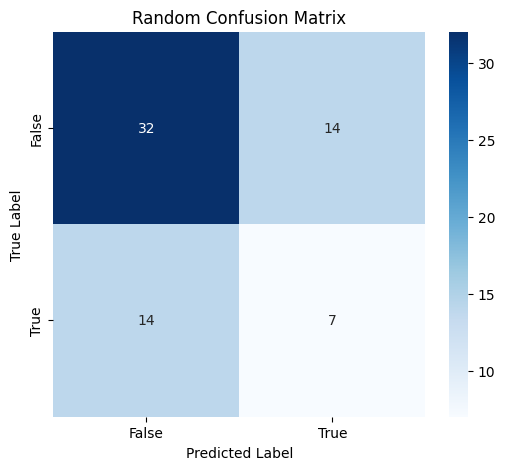

In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Confusion Matrix + Heatmap ---
# (Assumes you already have y_test and y_pred defined)

# 1. Compute confusion matrix
cm = confusion_matrix(y_test, random.sample(list(y_test), len(list(y_test))))

# 2. Create labeled DataFrame for readability
labels = sorted(list(set(y_test)))  # auto-detect unique class labels
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

# 3. Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title("Random Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

#DATA VIZ

In [1]:
from google.colab import files
uploaded = files.upload()

Saving all_years.xlsx to all_years.xlsx


In [2]:
import pandas as pd

df = pd.read_excel("all_years.xlsx")
#df = pd.read_excel("artemis_dataset_release_v0_sorted.xlsx")

print(df.head())

     game_id       date  season home_short_display_name  home_SRS  home_SOS  \
0  401522202 2023-04-03    2023                   UConn     22.95      8.51   
1  401522200 2023-04-01    2023            San Diego St     15.81      8.92   
2  401522201 2023-04-01    2023                   UConn     22.95      8.51   
3  401522199 2023-03-26    2023            San Diego St     15.81      8.92   
4  401522196 2023-03-26    2023                   Texas     20.56     10.43   

   home_Tm.  home_Opp.  home_MP  home_FG  ...  away_AST%  away_STL%  \
0      78.6       64.1     40.0     27.7  ...       51.1       10.0   
1      71.2       63.5     40.3     25.3  ...       51.8        9.4   
2      78.6       64.1     40.0     27.7  ...       50.6       10.5   
3      71.2       63.5     40.3     25.3  ...       57.3        7.2   
4      78.0       67.8     40.4     28.5  ...       50.6       10.5   

   away_BLK%  away_eFG%  away_TOV%  away_ORB%  away_FT/FGA  home_score  \
0       11.7      0.498 

In [ ]:
y2023 = df.query("season == 2023")
y2022 = df.query("season == 2022")
y2021 = df.query("season == 2021")
y2019 = df.query("season == 2019")
y2018 = df.query("season == 2018")
y2017 = df.query("season == 2017")
y2016 = df.query("season == 2016")
y2015 = df.query("season == 2015")
y2014 = df.query("season == 2014")
y2013 = df.query("season == 2013")
y2012 = df.query("season == 2012")
y2011 = df.query("season == 2011")
y2010 = df.query("season == 2010")
y2009 = df.query("season == 2009")
y2008 = df.query("season == 2008")
y2007 = df.query("season == 2007")
y2006 = df.query("season == 2006")
y2005 = df.query("season == 2005")
y2004 = df.query("season == 2004")
y2003 = df.query("season == 2003")
y2002 = df.query("season == 2002")

In [ ]:
import matplotlib.pyplot as plt

In [4]:
under_dog_wins = df['underdog_winner'].value_counts()

print(under_dog_wins)

underdog_winner
False    954
True     417
Name: count, dtype: int64


In [6]:
under_dog_wins23 = df.query("season == 2023")['underdog_winner'].value_counts()
under_dog_wins22 = df.query("season == 2022")['underdog_winner'].value_counts()
under_dog_wins21 = df.query("season == 2021")['underdog_winner'].value_counts()
under_dog_wins19 = df.query("season == 2019")['underdog_winner'].value_counts()
under_dog_wins18 = df.query("season == 2018")['underdog_winner'].value_counts()
under_dog_wins17 = df.query("season == 2017")['underdog_winner'].value_counts()
under_dog_wins16 = df.query("season == 2016")['underdog_winner'].value_counts()
under_dog_wins15 = df.query("season == 2015")['underdog_winner'].value_counts()
under_dog_wins14 = df.query("season == 2014")['underdog_winner'].value_counts()
under_dog_wins13 = df.query("season == 2013")['underdog_winner'].value_counts()
under_dog_wins12 = df.query("season == 2012")['underdog_winner'].value_counts()
under_dog_wins11 = df.query("season == 2011")['underdog_winner'].value_counts()
under_dog_wins10 = df.query("season == 2010")['underdog_winner'].value_counts()
under_dog_wins09 = df.query("season == 2009")['underdog_winner'].value_counts()
under_dog_wins08 = df.query("season == 2008")['underdog_winner'].value_counts()
under_dog_wins07 = df.query("season == 2007")['underdog_winner'].value_counts()
under_dog_wins06 = df.query("season == 2006")['underdog_winner'].value_counts()
under_dog_wins05 = df.query("season == 2005")['underdog_winner'].value_counts()
under_dog_wins04 = df.query("season == 2004")['underdog_winner'].value_counts()
under_dog_wins03 = df.query("season == 2003")['underdog_winner'].value_counts()
under_dog_wins02 = df.query("season == 2002")['underdog_winner'].value_counts()

print(under_dog_wins23)
print(under_dog_wins22)
print(under_dog_wins21)
print(under_dog_wins19)
print(under_dog_wins18)
print(under_dog_wins17)
print(under_dog_wins16)
print(under_dog_wins15)
print(under_dog_wins14)
print(under_dog_wins13)
print(under_dog_wins12)
print(under_dog_wins11)
print(under_dog_wins10)
print(under_dog_wins09)
print(under_dog_wins08)
print(under_dog_wins07)
print(under_dog_wins06)
print(under_dog_wins05)
print(under_dog_wins04)
print(under_dog_wins03)
print(under_dog_wins02)

underdog_winner
False    46
True     21
Name: count, dtype: int64
underdog_winner
False    44
True     23
Name: count, dtype: int64
underdog_winner
False    44
True     23
Name: count, dtype: int64
underdog_winner
False    46
True     21
Name: count, dtype: int64
underdog_winner
False    44
True     23
Name: count, dtype: int64
underdog_winner
False    50
True     15
Name: count, dtype: int64
underdog_winner
False    44
True     23
Name: count, dtype: int64
underdog_winner
False    51
True     16
Name: count, dtype: int64
underdog_winner
False    42
True     25
Name: count, dtype: int64
underdog_winner
False    44
True     23
Name: count, dtype: int64
underdog_winner
False    47
True     20
Name: count, dtype: int64
underdog_winner
False    43
True     24
Name: count, dtype: int64
underdog_winner
False    43
True     21
Name: count, dtype: int64
underdog_winner
False    47
True     17
Name: count, dtype: int64
underdog_winner
False    48
True     15
Name: count, dtype: int64
underdog_w

In [8]:
counts = df.groupby(['season', 'underdog_winner']).size().unstack(fill_value=0)
print(counts)

underdog_winner  False  True 
season                       
2002                46     17
2003                42     21
2004                47     16
2005                43     20
2006                42     21
2007                51     12
2008                48     15
2009                47     17
2010                43     21
2011                43     24
2012                47     20
2013                44     23
2014                42     25
2015                51     16
2016                44     23
2017                50     15
2018                44     23
2019                46     21
2021                44     23
2022                44     23
2023                46     21


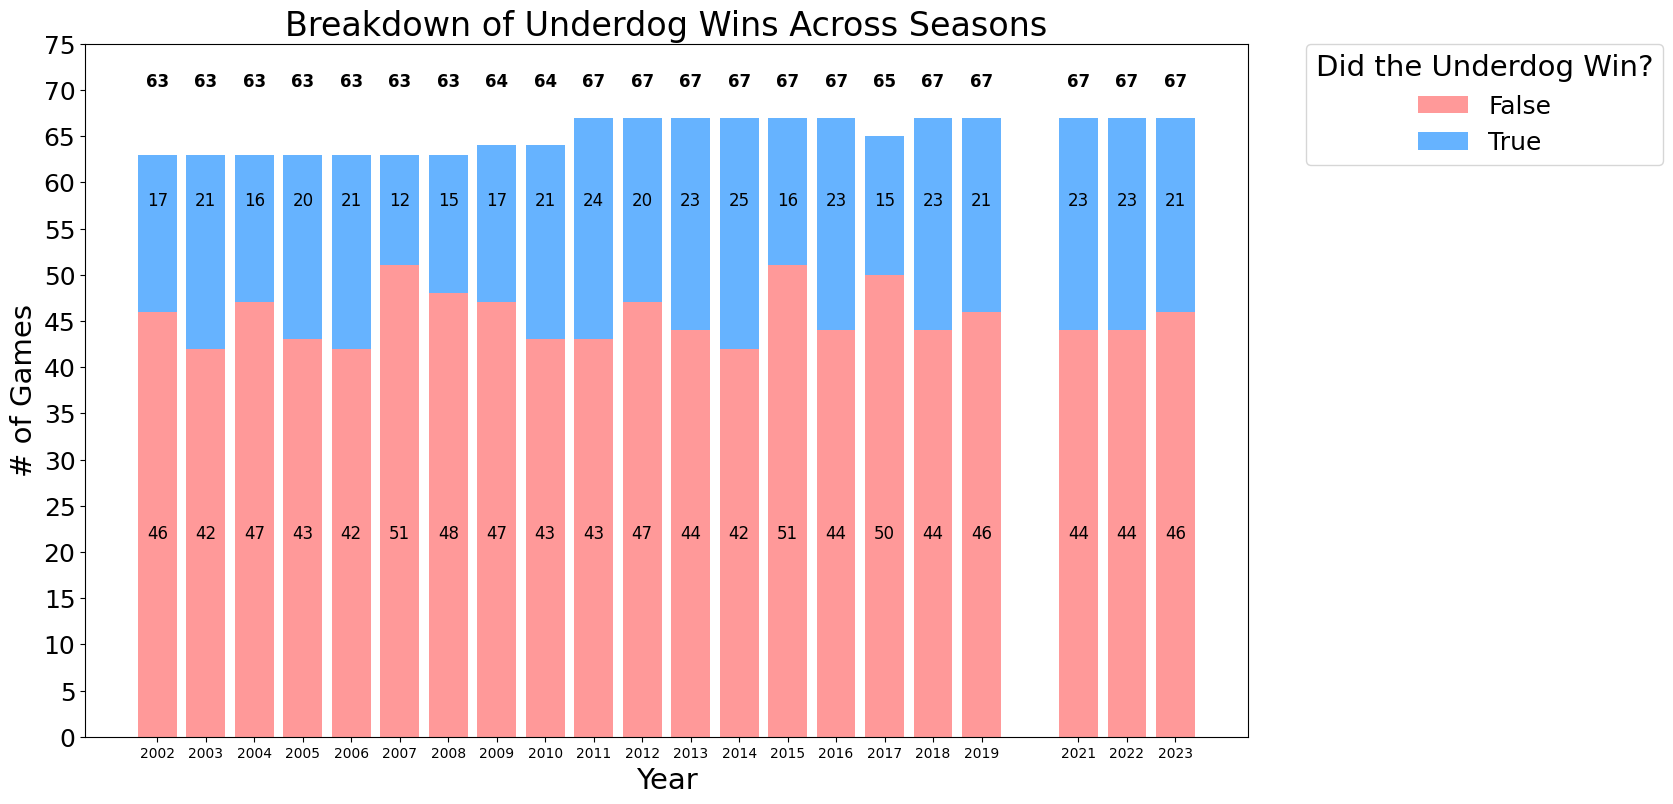

In [17]:
import matplotlib.pyplot as plt

years = sorted([int(year) for year in df['season'].unique()])

# Extract counts
false_counts = counts[False]
true_counts = counts[True]
totals = false_counts + true_counts

plt.figure(figsize=(15, 9))

# Plot stacked bars
bar1 = plt.bar(years, false_counts, label='False', color='#ff9999')
bar2 = plt.bar(years, true_counts, bottom=false_counts, label='True', color='#66b3ff')

# 🔹 Manually fix y positions for text
y_false = 22   # height for all "False" labels
y_true  = 58   # height for all "True" labels
y_total = 70   # height for all totals

# Add each set of labels at fixed y positions
for x, f, t, total in zip(years, false_counts, true_counts, totals):
    plt.text(x, y_false, str(f), ha='center', va='center', fontsize=12, color='black')
    plt.text(x, y_true, str(t), ha='center', va='center', fontsize=12, color='black')
    plt.text(x, y_total, str(total), ha='center', va='bottom', fontsize=12, fontweight='bold')

# Labels and title
plt.xlabel('Year')
plt.xticks(years)
plt.ylabel('# of Games')
plt.yticks(range(0, 79, 5))
plt.title('Breakdown of Underdog Wins Across Seasons')
plt.legend(title='Did the Underdog Win?', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.rcParams.update({
    'font.size': 21,
    'axes.titlesize': 24,
    'axes.labelsize': 21,
    'xtick.labelsize': 10,
    'ytick.labelsize': 18,
    'legend.fontsize': 18,
})

plt.show()


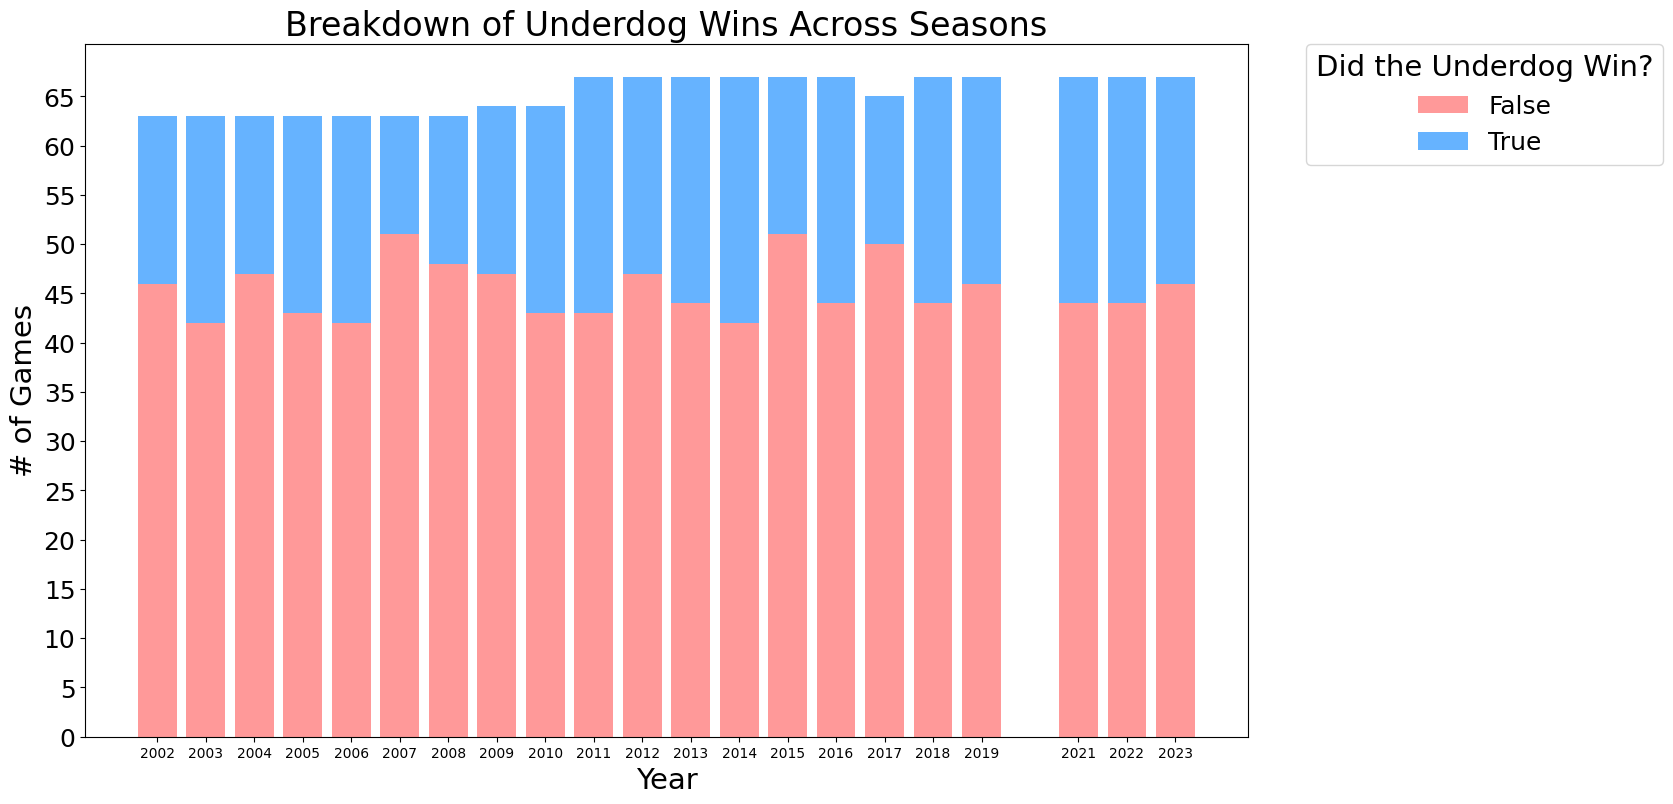

In [11]:
import matplotlib.pyplot as plt

years = sorted([int(year) for year in df['season'].unique()])

# Extract counts for False and True
false_counts = counts[False]
true_counts = counts[True]

plt.figure(figsize=(15, 9))

# Plot stacked bars
plt.bar(years, false_counts, label='False', color='#ff9999')
plt.bar(years, true_counts, bottom=false_counts, label='True', color='#66b3ff')

# Labels and title
plt.xlabel('Year')
plt.xticks(years)
plt.ylabel('# of Games')
plt.yticks(range(0,70,5))
plt.title('Breakdown of Underdog Wins Across Seasons')
plt.legend(title='Did the Underdog Win?', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Show the plot
plt.show()
plt.rcParams.update({
    'font.size': 21,        # default text size
    'axes.titlesize': 24,   # title size
    'axes.labelsize': 21,   # x and y labels
    'xtick.labelsize': 10,  # x tick labels
    'ytick.labelsize': 18,  # y tick labels
    'legend.fontsize': 18,  # legend text
})

plt.show()

#MODEL CREATION

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving cbb_playoffs_2005-2023.xlsx to cbb_playoffs_2005-2023 (2).xlsx


In [ ]:
import pandas as pd

df = pd.read_excel("cbb_playoffs_2005-2023.xlsx")
#df = pd.read_excel("artemis_dataset_release_v0_sorted.xlsx")

print(df.head())

               Team  Team_ID   FG%   3P%    FT%  TRB  ORB  AST  STL  BLK  ...  \
0   San Diego State       21  32.2  26.1   75.0   34   12    7    7    2  ...   
1             UConn       41  43.4  35.3   88.9   40   10   13    8    6  ...   
2             Miami     2390  32.3  35.0  100.0   32   14   10    8    1  ...   
3             UConn       41  49.1  34.6   53.8   41   13   19    5    5  ...   
4  Florida Atlantic     2226  44.2  40.9   76.2   34    8    6    6    2  ...   

   oFTM  oFTA   oFT%  oORB  oTRB  oAST  oSTL  oBLK  oTOV   oPF  
0  24.0  27.0   88.9  10.0  40.0  13.0   8.0   6.0  13.0  15.0  
1  15.0  20.0   75.0  12.0  34.0   7.0   7.0   2.0  12.0  20.0  
2   7.0  13.0   53.8  13.0  41.0  19.0   5.0   5.0  15.0  11.0  
3  12.0  12.0  100.0  14.0  32.0  10.0   8.0   1.0   9.0  12.0  
4  13.0  22.0   59.1  12.0  35.0   8.0   3.0   2.0   8.0  17.0  

[5 rows x 60 columns]


##Columns to remove
- Team
- Team_ID
- Game_ID
- opponent_id_combined

##Columns to alter
- Datetime (make just time)
- Season_Type
- season_type_encoded (redundant)

##Columns to predict
- Team_Score
- Team_Win
- Opp_Score
- team_winner_encoded (redundant)

##Important
- home/away corresponds to higher seed

In [ ]:
print(df["Datetime"])

df["time"] = df["Datetime"].apply(lambda x: str(x).split(" ")[1] if str(x) != "nan" else None)

df["underdog"] = df["Site"].apply(lambda x: "underdog" if x == "away" else "favorite")

print(df["underdog"])

0       2023-04-04 01:20:00+00:00
1       2023-04-04 01:20:00+00:00
2       2023-04-02 01:16:00+00:00
3       2023-04-02 01:16:00+00:00
4       2023-04-01 22:09:00+00:00
                  ...            
2379                          NaN
2380                          NaN
2381                          NaN
2382                          NaN
2383                          NaN
Name: Datetime, Length: 2384, dtype: object
0       underdog
1       favorite
2       underdog
3       favorite
4       underdog
          ...   
2379    underdog
2380    favorite
2381    underdog
2382    favorite
2383    underdog
Name: underdog, Length: 2384, dtype: object


In [ ]:
df = df.drop(columns=["Team", "Team_ID", "Game_ID", "opponent_id_combined", "Datetime", "season_type_encoded", "team_winner_encoded"])

KeyError: "['Team', 'Team_ID', 'Game_ID', 'opponent_id_combined', 'Datetime', 'season_type_encoded', 'team_winner_encoded'] not found in axis"

In [ ]:
y2023 = df.query("Season == 2023")
y2022 = df.query("Season == 2022")
y2010 = df.query("Season == 2010")
y2009 = df.query("Season == 2009")
y2008 = df.query("Season == 2008")
y2007 = df.query("Season == 2007")
y2006 = df.query("Season == 2006")
y2005 = df.query("Season == 2005")

print(y2023.head())
#print(y2022.head())
#print(y2010.head())
#print(y2009.head())
#print(y2008.head())
#print(y2007.head())
#print(y2006.head())
#print(y2005.head())

    FG%   3P%    FT%  TRB  ORB  AST  STL  BLK  turnovers  team_turnovers  ...  \
0  32.2  26.1   75.0   34   12    7    7    2         12               0  ...   
1  43.4  35.3   88.9   40   10   13    8    6         13               0  ...   
2  32.3  35.0  100.0   32   14   10    8    1          9               0  ...   
3  49.1  34.6   53.8   41   13   19    5    5         15               1  ...   
4  44.2  40.9   76.2   34    8    6    6    2         10               1  ...   

   oFTA   oFT%  oORB  oTRB  oAST  oSTL  oBLK  oTOV   oPF            time  
0  27.0   88.9  10.0  40.0  13.0   8.0   6.0  13.0  15.0  01:20:00+00:00  
1  20.0   75.0  12.0  34.0   7.0   7.0   2.0  12.0  20.0  01:20:00+00:00  
2  13.0   53.8  13.0  41.0  19.0   5.0   5.0  15.0  11.0  01:16:00+00:00  
3  12.0  100.0  14.0  32.0  10.0   8.0   1.0   9.0  12.0  01:16:00+00:00  
4  22.0   59.1  12.0  35.0   8.0   3.0   2.0   8.0  17.0  22:09:00+00:00  

[5 rows x 54 columns]
